In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#Loads the MNIST dataset, downsamples the images to 14x14, and converts them to binary.
transform = transforms.Compose([
    transforms.Resize((14, 14)), #resizes to 14x14
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())#convert to binary
])

#Load MNIST dataset and apply transformations
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

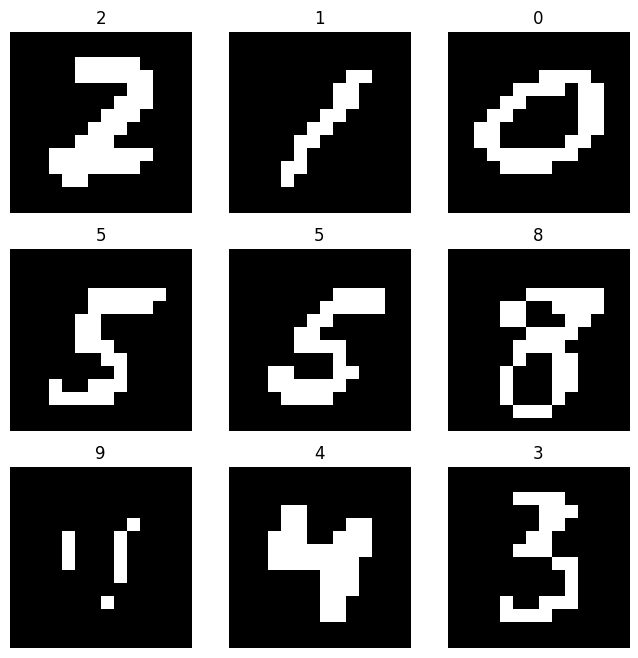

In [ ]:
show_images(train_dataset, 3, 3)

In [ ]:
class BinaryConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
        super(BinaryConvLayer, self).__init__()

        # Initialize weights with a normal distribution
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

        # Apply 4-bit quantization to weights
        self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  # Scale to 4 bits (between 0 and 15)

        # Use ReLU activation
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        return x

# Step 3: Create a simple CNN model with one convolutional layer
class SimpleCNN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(SimpleCNN, self).__init__()
        self.conv1 = BinaryConvLayer(in_channels, out_channels, kernel_size, stride, padding)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(6 * 14 * 14, 10)  # Output 10 units for MNIST classes

    def forward(self, x):
        x = self.conv1(x)  #Apply convolutional layer
        x = self.flatten(x)  #Flatten the feature maps
        x = self.fc(x)  #Fully connected layer to produce class logits (no sigmoid)
        return x

In [ ]:
myCNN = SimpleCNN(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(myCNN)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

SimpleCNN(
  (conv1): BinaryConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=1176, out_features=10, bias=True)
)


In [ ]:
#test output shape
for images, labels in train_loader:
    output = myCNN(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([64, 10])


In [ ]:
def create_sgd_optimizer(model, learning_rate=0.001, momentum=0):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = create_sgd_optimizer(myCNN)

In [ ]:
#training model
def train_model(model, train_loader, optimzer, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = myCNN(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [ ]:
train_model(myCNN, train_loader, optimizer, loss_fn=loss_fn, epochs=10)

Epoch 1/10, Loss: 2.2688, Accuracy: 27.56%
Epoch 2/10, Loss: 2.1106, Accuracy: 52.08%
Epoch 3/10, Loss: 1.6387, Accuracy: 71.34%
Epoch 4/10, Loss: 1.1037, Accuracy: 77.69%
Epoch 5/10, Loss: 0.8237, Accuracy: 80.23%
Epoch 6/10, Loss: 0.6958, Accuracy: 81.56%
Epoch 7/10, Loss: 0.6294, Accuracy: 82.40%
Epoch 8/10, Loss: 0.5901, Accuracy: 82.96%
Epoch 9/10, Loss: 0.5641, Accuracy: 83.42%
Epoch 10/10, Loss: 0.5463, Accuracy: 83.77%
Training complete


In [ ]:
#save model
torch.save(myCNN.state_dict(), './cnn_4bitquant.pth')

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
#test the model on the MNIST testing data split
evaluate_model(myCNN, test_loader)

85.13